## Genomics

Leukemia is a cancer of blood-generating tissues. Over 475,000 Americans have Leukemia or are in remission from it. It accounts for 3.3% of all new cancer cases and 3.8% of cancer deaths, with an estimated 66,890 new cases and 23,540 deaths in the U.S. in 2025.

There are two major leukemia families: Acute Lymphoblastic Leukemia (ALLB and ALLT, or ALL), which is cancer of immature lymphoid cells, and Acute Myeloid Leukemia (AML), which is cancer of cancer of immature myeloid cells.

Golub et al. (*Science*, 1999) popularized a dataset including about 7000 genes from 72 patients. The goal is to use genomics data to predict which patients are at risk of ALL versus AML, because the distinction is critical for timely and effective treatment.

1. Load the `golub.csv` dataset. Relabel all instances of ALLB and ALLT as 0, and all instances of ALL as 1. This is the target variable.

2. Use Linear Regression of the target variable on all of the genes provided. What is your mean squared error? Make a kernel density plot of your residuals, and a scatter plot comparing predicted and actual outcomes.

3. Use cross validation to compute the mean squared error of the linear model. Discuss your results from the perspective of the bias variance trade-off.

4. Use the cross validated LASSO to select a set of highly predictive genes. Which set of genes is selected? How many genes are discarded from the model? Make a scatterplot of your predictions versus the actual values.

5. Make a plot that shows the cross validated MSE as $alpha$ varies. For what values of $\alpha$ is the LASSO underfitting? Overfitting? What is the optimal penality hyperparameter that minimizes expected MSE?

6. Explain why linear regression performs perfectly on the training set, but the LASSO provides better predictions overall.

7. Why do regularization methods lend themselves to scenarios like precision health?

8. What are the risks of applying methods like the Lasso to precision health questions, where interventions will then be taken to optimize patient health?

Load the golub.csv dataset. Relabel all instances of ALLB and ALLT as 0, and all instances of ALL as 1. This is the target variable.

In [36]:
#Question One
#importing libraries needed
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler

In [37]:
#Question One (continued)
#load the data
df = pd.read_csv('golub.csv')
df.head()

,Samples,BM.PB,Gender,Source,tissue.mf,cancer,AFFX-BioB-5_at,AFFX-BioB-M_at,AFFX-BioB-3_at,AFFX-BioC-5_at,...,U48730_at,U58516_at,U73738_at,X06956_at,X16699_at,X83863_at,Z17240_at,L49218_f_at,M71243_f_at,Z78285_f_at
0,39,BM,F,DFCI,BM:f,allB,-1363.276427,-1058.585495,-541.469194,74.349803,...,-35.081447,1565.618803,-485.680714,-170.261227,-919.114293,1675.050053,389.769289,-526.449219,-268.963924,-779.643092
1,40,BM,F,DFCI,BM:f,allB,-796.285053,-1167.103365,7.538493,83.544731,...,-404.737767,622.498054,-1275.354673,214.828233,-750.220666,-441.589276,9.841713,-671.911209,-671.911209,-644.272577
2,42,BM,F,DFCI,BM:f,allB,-679.139168,-1069.832308,-690.301829,-112.075981,...,193.780934,162.525483,-692.534361,517.498108,-674.674103,1265.396405,-65.192805,-714.859684,3672.066149,-822.021231
3,47,BM,M,DFCI,BM:m,allB,-1164.400197,-1109.939891,-990.127218,-238.574994,...,-256.002292,-31.625831,-621.975549,-458.594630,-630.689198,937.767618,-264.715941,-635.046022,475.944222,-794.070116
4,48,BM,F,DFCI,BM:f,allB,-1299.653758,-1401.998536,-1077.543813,-437.344560,...,-509.203660,383.591216,-905.517483,-36.675640,-1116.739685,316.087213,-210.879518,-953.423549,-291.448812,-1057.945876


In [38]:
#Question One (Continued)
# Replace labels and ensure numerical type
df['target'] = df['cancer'].replace({
    'allB': 0,
    'allT': 0,
    'aml': 1
}).astype(int)

# Drop original label column 'cancer' as it's now represented by 'target'
df = df.drop(columns=['cancer'])

# Define non-gene metadata columns that should not be part of the features
non_gene_metadata_columns = ['Samples', 'BM.PB', 'Gender', 'Source', 'tissue.mf']

# Features (X) exclude non-gene metadata columns and the target variable
X = df.drop(columns=non_gene_metadata_columns + ['target'])

# Target variable (y)
y = df['target']

/tmp/ipykernel_692/2869080329.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['target'] = df['cancer'].replace({


In [39]:
#Question Two
model = LinearRegression()
model.fit(X, y)

y_pred = model.predict(X)

mse = mean_squared_error(y, y_pred)
print("Training MSE:", mse)

Training MSE: 1.2522824482837894e-30


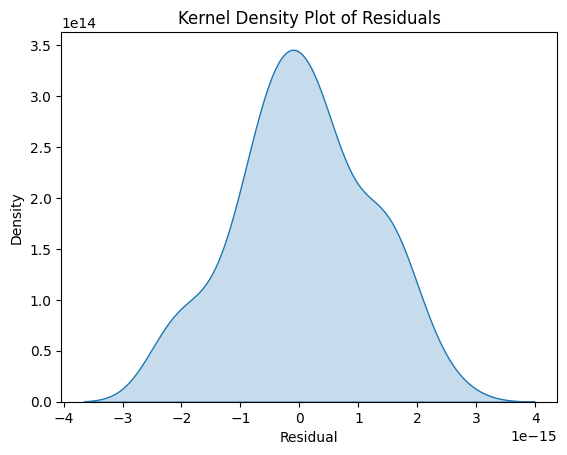

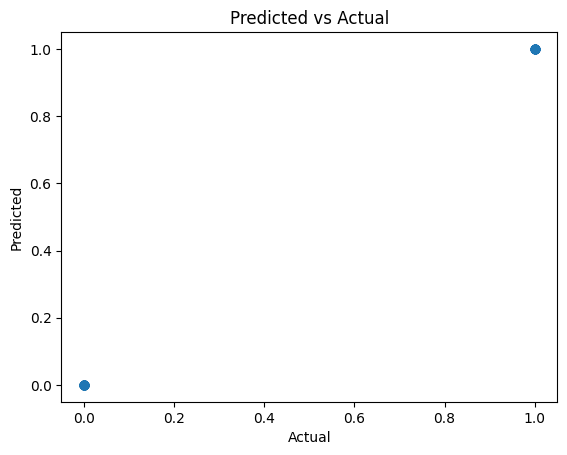

In [40]:
#Question Two (continued)
#residual analysis
residuals = y - y_pred

# Kernel density plot
sns.kdeplot(residuals, fill=True)
plt.title("Kernel Density Plot of Residuals")
plt.xlabel("Residual")
plt.show()

# Predicted vs Actual
plt.scatter(y, y_pred)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Predicted vs Actual")
plt.show()

In [41]:
#Question Three (Continued)
from sklearn.model_selection import cross_val_score
cv_mse = -cross_val_score(model, X, y,
                         scoring='neg_mean_squared_error',
                         cv=5)

print("Cross-validated MSE:", cv_mse.mean())

Cross-validated MSE: 0.06012309872062149


Question Three (Continued): Discuss your results from the perspective of the bias variance trade-off:
The linear regression uses all genes, which means that there is very high dimensional. The training MSE is very low and is nearing zero, which means that there is an overfitting.

In [42]:
#Question four
from sklearn.linear_model import LassoCV

lasso = LassoCV(cv=5, random_state=0)
lasso.fit(X, y)

y_lasso_pred = lasso.predict(X)

print("Optimal alpha:", lasso.alpha_)

Optimal alpha: 105.24436668425457


In [43]:
coef = pd.Series(lasso.coef_, index=X.columns)

selected_genes = coef[coef != 0]
print("Selected genes:", selected_genes.index.tolist())
print("Number selected:", len(selected_genes))
print("Number discarded:", X.shape[1] - len(selected_genes))

Selected genes: ['HG3549-HT3751_at', 'J04164_at', 'L38941_at', 'M11147_at', 'M11722_at', 'M17733_at', 'M19507_at', 'M26602_at', 'M27891_at', 'M33680_at', 'M63138_at', 'M77232_rna1_at', 'M91036_rna1_at', 'M96326_rna1_at', 'U14968_at', 'X04500_at', 'X17042_at', 'X78992_at', 'Z70759_at', 'L06797_s_at', 'D49824_s_at', 'M25079_s_at', 'X57351_s_at', 'V00594_s_at', 'U05255_s_at', 'X03689_s_at', 'M14328_s_at', 'M14483_rna1_s_at', 'M26708_s_at', 'Y00787_s_at', 'Z19554_s_at', 'X56681_s_at', 'HG2887-HT3031_at', 'M33600_f_at']
Number selected: 34
Number discarded: 7095


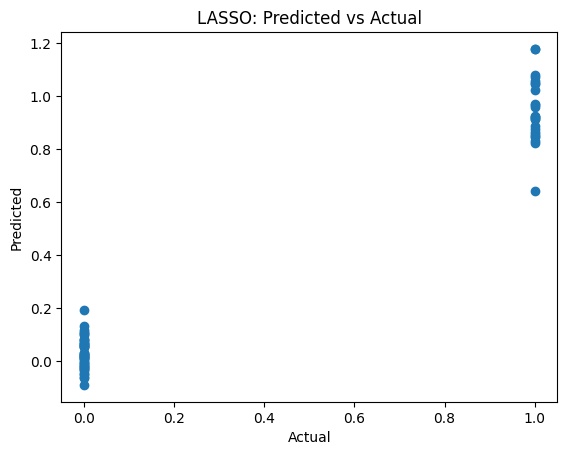

In [44]:
plt.scatter(y, y_lasso_pred)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("LASSO: Predicted vs Actual")
plt.show()

Question Five: Make a plot that shows the cross validated MSE as  alpha  varies. For what values of  α  is the LASSO underfitting? Overfitting? What is the optimal penality hyperparameter that minimizes expected MSE?
underfitting large alpha values on right side due to lots of shrinkage. Overfitting on left side due to the model keeping many of the genes. The optimal value of alpha is found in lasso alpha.

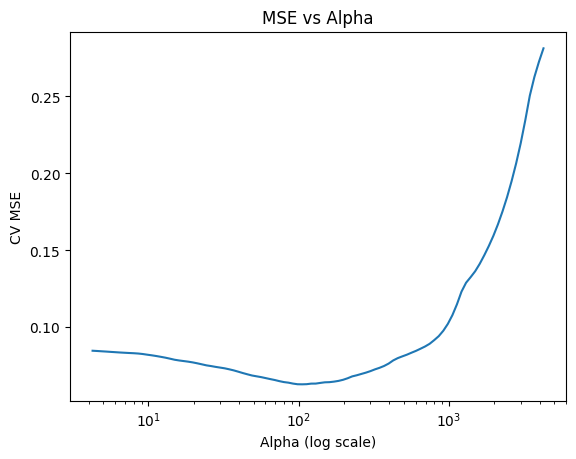

In [45]:
#cross validating MSE vs Alpha
mse_path = lasso.mse_path_.mean(axis=1)
alphas = lasso.alphas_

plt.plot(alphas, mse_path)
plt.xscale('log')
plt.xlabel("Alpha (log scale)")
plt.ylabel("CV MSE")
plt.title("MSE vs Alpha")
plt.show()

Question Six: Explain why linear regression performs perfectly on the training set, but the LASSO provides better predictions overall. Linear regression performs perfectly on the training set because p is greater than n, meaning that there are more genes than samples. The model can exactly interpolate data. This can sometimes lead to overfitting. LASSO performs better because it adds regularization penalty. It can also shrink irrelevant coefficients to zero. It also reduces variance, which helps improve the overall generalization.

Question Seven: Why is regularization useful in precision health?
The health data being used has thousands of genes, but also few patients. Using LASSO allows for important biomarkers to be identified.It also improves prediction reliability, and it can allow easily understandable models to be created.

Question Eight: The risks of LASSO in precision health is that it may select the wrong genes due to noise (data) within the analyses trying be done. It could also miss important interactions needed, and make the wrong decision. Also having an unstable dataset could cause more problem, and this could lead to incorrect decisions to be made and overconfidence in the biomarker that was selected.